#  ***Netflix Data Analysis***

## **Table of Contents**
1. Data Loading
2. Data Exploration
3. Data Cleaning
4. Movies vs TV Shows
5. Top 10 Genres
6. Top 15 Countries
7. Netflix Content Growth Over the Years
8. Movies Added to Netflix Over the Years
9. TV Shows Added to Netflix Over the Years
10. Distribution of Content Ratings on Netflix
11. Final Conclusions


## **Data loading**

In [93]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [94]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Data Science/Netflix/netflix_titles.csv')

## **Data Exploration**

In [100]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [102]:
df.describe()

,release_year
count,8794.000000
mean,2014.183534
std,8.823527
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [99]:
df.shape

(8794, 12)

In [96]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [97]:
df['director']=df['director'].fillna('unknown')
df['cast']=df['cast'].fillna('unknown')
df['country']=df['country'].fillna('unknown')
df['rating']=df['rating'].fillna('unknown')


In [98]:
df=df.dropna(subset='date_added')
df=df.dropna(subset='duration')

In [10]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


## **Data cleaning**

In [11]:
df['date_added'].head()

,date_added
0,"September 25, 2021"
1,"September 24, 2021"
2,"September 24, 2021"
3,"September 24, 2021"
4,"September 24, 2021"


In [12]:
df['date_added']=pd.to_datetime(df['date_added'] , format='mixed')

In [13]:
df['date_added'].head(10)

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24
5,2021-09-24
6,2021-09-24
7,2021-09-24
8,2021-09-24
9,2021-09-24


# ***Distribution of Movies and TV Shows on Netflix***

In [74]:
Movie_TVShows_df=df.copy()


In [75]:
Movie_TVShows_df['type'].head(10)

,type
0,Movie
1,TV Show
1,TV Show
1,TV Show
2,TV Show
2,TV Show
2,TV Show
3,TV Show
3,TV Show
4,TV Show


# **Methodology**

- Counted the number of Movies and TV Shows using the `type` column.
- Calculated the frequency of each content type using `value_counts()`.
- Visualized the distribution using a vertical bar chart.
- Added data labels to display the exact number of titles for each content type.

In [71]:
Movie_TVShows_df['type'].value_counts()

,count
type,
Movie,13187
TV Show,6113


In [61]:
type_counts=df['type'].value_counts()


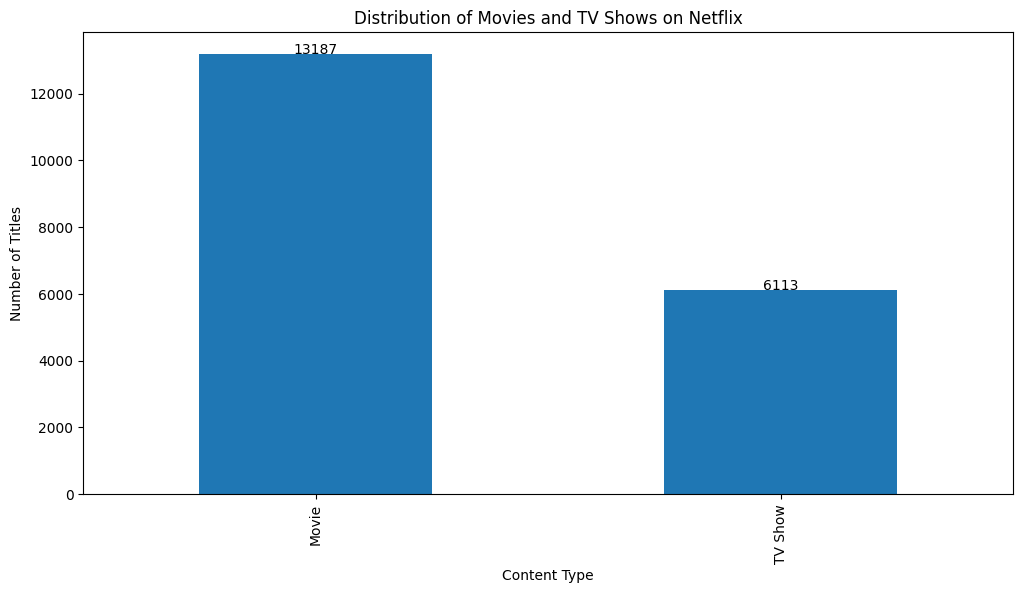

In [73]:
import matplotlib.pyplot as plt
type_counts.plot(kind='bar',figsize=(12,6))
plt.title('Distribution of Movies and TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

for o , b in enumerate(type_counts):
  plt.text(o,b+10,str(b),ha='center')
plt.show()

# **Key Insights**

1. Movies make up the majority of Netflix's catalog, significantly outnumbering TV Shows.

2. TV Shows represent a smaller share of the catalog, indicating that Netflix offers more movie content than serialized content.

3. The distribution suggests that Netflix has historically focused more on expanding its movie library.

# ***Top 10 Genres on Netflix***




In [76]:
genres_df=df.copy()

In [77]:
genres_df['listed_in'].head()

,listed_in
0,Documentaries
1,International TV Shows
1,TV Dramas
1,TV Mysteries
2,Crime TV Shows


# **Methodology**

- Split the `listed_in` column by commas.
- Used `explode()` to separate multiple genres into individual rows.
- Removed leading and trailing spaces from genre names using `str.strip()`.
- Counted the frequency of each genre using `value_counts()`.
- Visualized the Top 10 genres using a horizontal bar chart.

In [78]:
genres_df['listed_in']=genres_df['listed_in'].str.split(',')

In [79]:
genres_df=genres_df.explode('listed_in')

In [80]:
genres_df['listed_in'].str.strip()

,listed_in
0,Documentaries
1,International TV Shows
1,TV Dramas
1,TV Mysteries
2,Crime TV Shows
...,...
8805,Children & Family Movies
8805,Comedies
8806,Dramas
8806,International Movies


In [81]:
genres_df['listed_in'].value_counts().head(10)

,count
listed_in,
International Movies,2624
Dramas,1600
Comedies,1210
Action & Adventure,859
Documentaries,829
Dramas,827
International TV Shows,773
Independent Movies,736
TV Dramas,695


In [82]:
top_genres=genres_df['listed_in'].value_counts().head(10)

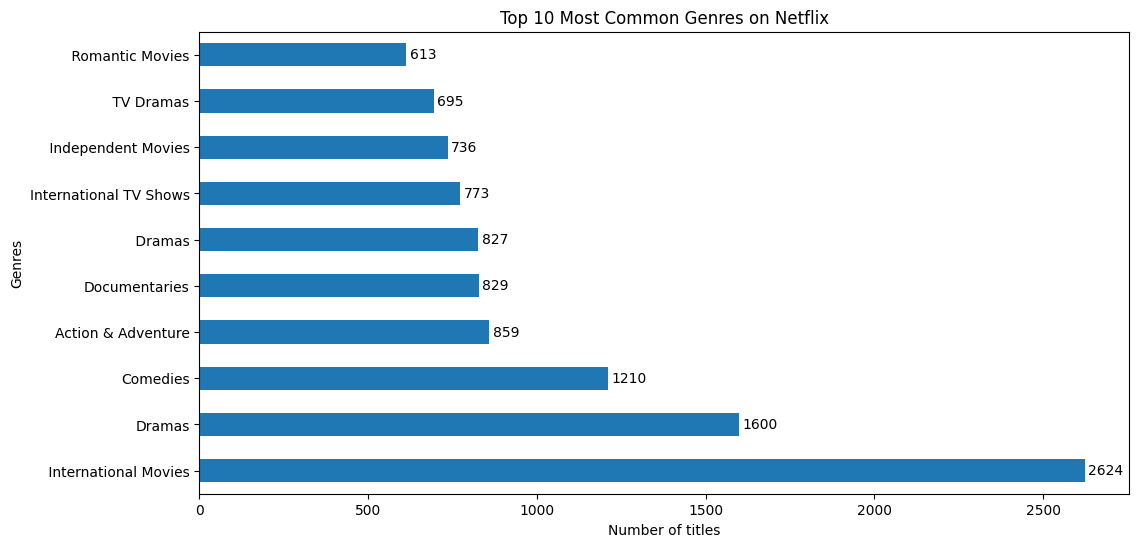

In [64]:
ax=top_genres.plot(kind='barh',figsize=(12,6))
plt.title('Top 10 Most Common Genres on Netflix')
plt.xlabel('Number of titles')
plt.ylabel('Genres')

for i , v in enumerate(top_genres):
  ax.text(v+10,i,str(v),va='center')
plt.show()

# **Key Insights**

1. International Movies are the most common genre in Netflix's catalog, indicating a strong focus on international content.

2. Comedies and Dramas are also among the most represented genres, highlighting Netflix's emphasis on general entertainment.

3. Romantic Movies have the lowest number of titles among the Top 10 genres, making them less represented in the catalog than other major genres.**bold text**

# ***Top 15 Content-Producing Countries on Netflix***

In [21]:
country_df=df.copy()

In [22]:
country_df['country'].head(15)

,country
0,United States
1,South Africa
1,South Africa
1,South Africa
2,unknown
2,unknown
2,unknown
3,unknown
3,unknown
4,India


# **Methodology**

- Split the `country` column by commas.
- Used `explode()` to separate multiple countries into individual rows.
- Removed leading and trailing spaces from country names using `str.strip()`.
- Counted the frequency of each country using `value_counts()`.
- Visualized the Top 15 countries using a horizontal bar chart.

In [23]:
country_df['country'].str.split(',')

,country
0,[United States]
1,[South Africa]
1,[South Africa]
1,[South Africa]
2,[unknown]
...,...
8805,[United States]
8805,[United States]
8806,[India]
8806,[India]


In [24]:
country_df['country']=country_df['country'].str.split(',')

In [25]:
country_df=country_df.explode('country')

In [26]:
country_df['country'].value_counts().head(15)

,count
country,
United States,5740
India,2721
unknown,1721
United Kingdom,1410
United States,1025
Japan,617
South Korea,595
Canada,530
France,505


In [27]:
top_countries=country_df['country'].value_counts().head(15)

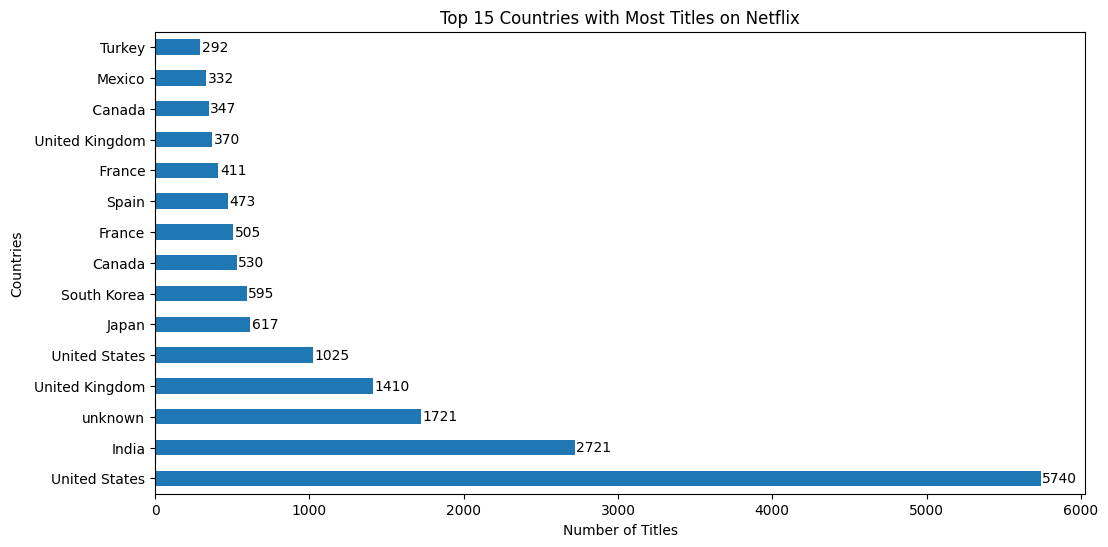

In [28]:
an=top_countries.plot(kind='barh',figsize=(12,6))
plt.title('Top 15 Countries with Most Titles on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Countries')

for j , p in enumerate(top_countries):
  an.text(p+10,j,str(p),va='center')

plt.show()

# **Key Insights**

1. The United States contributes the highest number of titles to Netflix's catalog, making it the leading content-producing country in the dataset.

2. A small number of titles have missing country information, indicating incomplete metadata in the dataset.

3. Among the Top 15 countries, Turkey contributes the fewest titles, suggesting a smaller representation in Netflix's catalog compared to other major contributors.


# ***Netflix Content Growth Over the Years***

In [29]:
growth_df=df.copy()

In [30]:
growth_df['date_added'].dt.year.head(10)

,date_added
0,2021
1,2021
1,2021
1,2021
2,2021
2,2021
2,2021
3,2021
3,2021
4,2021


# **Methodology**

- Extracted the year from the `date_added` column using `.dt.year`.
- Counted the number of titles added each year using `value_counts()`.
- Sorted the years in chronological order using `sort_index()`.
- Visualized the yearly content growth using a line chart with markers.

In [31]:
titles_per_year=growth_df['date_added'].dt.year.value_counts().sort_index()

In [32]:
titles_per_year.head(10)

,count
date_added,
2008,4
2009,3
2010,2
2011,19
2012,4
2013,23
2014,37
2015,152
2016,856


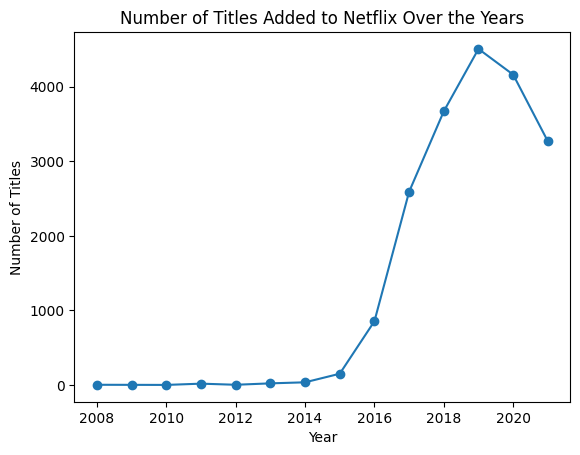

In [33]:
ak=titles_per_year.plot(kind='line',marker='o')
plt.title('Number of Titles Added to Netflix Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.grid=True
plt.show()

# **Key Insights**

1. The number of titles added to Netflix remained relatively low until 2015, indicating slow content expansion during the early years.

2. Netflix experienced rapid growth in content additions between 2016 and 2019, reflecting a significant expansion of its content library.

3. The number of titles added peaked in 2019 and declined in 2020 and 2021, indicating a slowdown in new content additions.

# ***Movies Added to Netflix Over the Years***

In [34]:
movies_df=df.copy()

In [35]:
movies_df[movies_df['type']=='Movie'].head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,Dramas,"On a photo shoot in Ghana, an American model s..."
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,Independent Movies,"On a photo shoot in Ghana, an American model s..."
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,International Movies,"On a photo shoot in Ghana, an American model s..."


# **Methodology**

- Filtered the dataset to include only `df_movies['type']=='Movie' `.
- Counted the number of movies added each year.
- Sorted the years in chronological order.
- Visualized the yearly trend using a line chart.

In [36]:
movies_per_year=movies_df[movies_df['type']=='Movie']['date_added'].dt.year.value_counts().sort_index()

In [37]:
movies_per_year.head(10)

,count
date_added,
2008,3
2009,3
2010,2
2011,19
2012,4
2013,10
2014,26
2015,98
2016,456


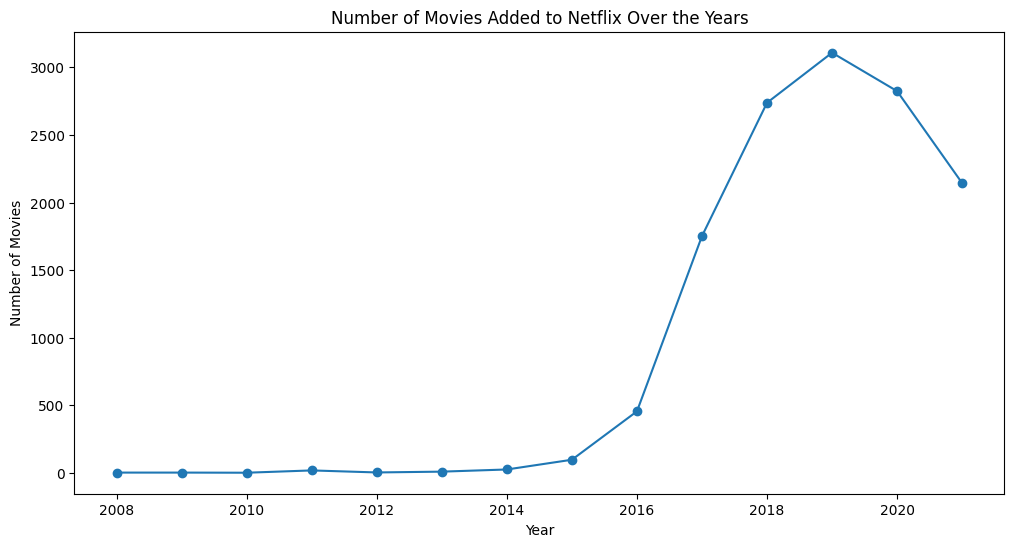

In [38]:
at=movies_per_year.plot(kind='line',marker='o',figsize=(12,6))
plt.title('Number of Movies Added to Netflix Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Movies')


plt.grid=True
plt.show()

# **Key Insights**

1. The number of movies added to Netflix remained relatively low between 2008 and 2014, indicating a gradual expansion of the movie catalog.

2. Movie additions increased rapidly from 2015 to 2019, reflecting Netflix's significant investment in expanding its movie library.

3. The number of movies added peaked in 2019 and declined in the following years, indicating a slowdown in movie additions.

# ***TV Shows  Added to Netflix Over the Years***

In [39]:
TV_Shows_df=df.copy()

In [40]:
TV_Shows_df[TV_Shows_df['type']=='TV Show'].head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,International TV Shows,To protect his family from a powerful drug lor...


# **Methodology**

- Filtered the dataset to include only `df_movies['type']=='TV Show' `.
- Counted the number of TV Shows  added each year.
- Sorted the years in chronological order.
- Visualized the yearly trend using a line chart.

In [41]:
TV_Shows_per_year=TV_Shows_df[TV_Shows_df['type']=='TV Show']['date_added'].dt.year.value_counts().sort_index()

In [42]:
TV_Shows_per_year.head(10)

,count
date_added,
2008,1
2013,13
2014,11
2015,54
2016,400
2017,840
2018,933
2019,1399
2020,1338


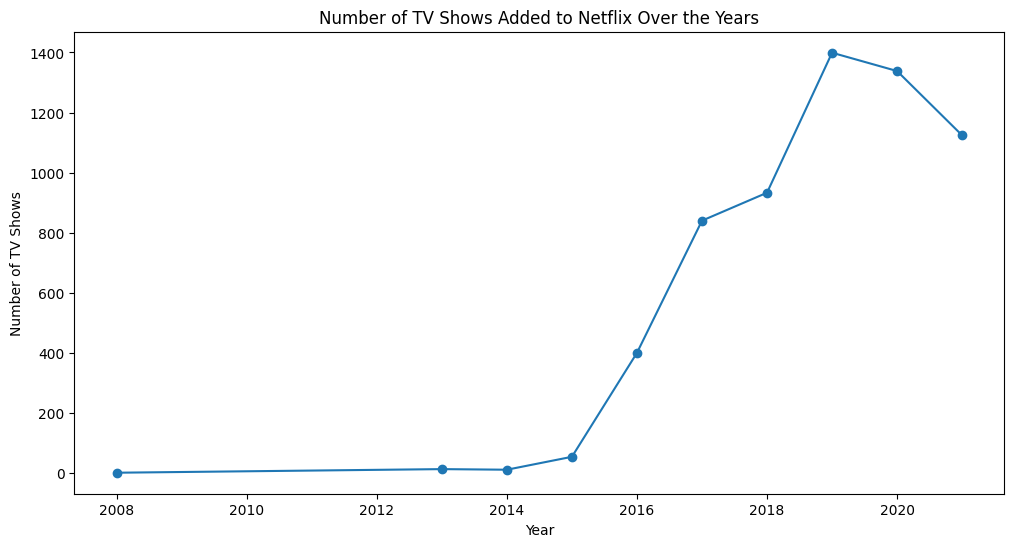

In [43]:
ab=TV_Shows_per_year.plot(kind='line',marker='o',figsize=(12,6))
plt.title('Number of TV Shows Added to Netflix Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of TV Shows')

plt.grid=True
plt.show()

# **Key Insights**

1. The number of TV Shows added to Netflix remained relatively low between 2008 and 2014, indicating a gradual expansion of Netflix's TV Show catalog.

2. TV Show additions increased rapidly between 2015 and 2019, reflecting a significant expansion of TV content during this period.

3. The number of TV Shows added peaked in 2019 and declined in the following years, indicating a slowdown in TV Show additions.

#***Distribution of Content Ratings on Netflix***

In [44]:
rating_df=df.copy()

In [46]:
rating_df['rating'].head(10)

,rating
0,PG-13
1,TV-MA
1,TV-MA
1,TV-MA
2,TV-MA
2,TV-MA
2,TV-MA
3,TV-MA
3,TV-MA
4,TV-MA


# **Methodology**


- Counted the frequency of each content rating using `value_counts()`.
- Selected the Top 10 most common content ratings.
- Visualized the distribution using a horizontal bar chart.
- Added data labels to improve readability.

In [50]:
rating_counts=rating_df['rating'].value_counts().head(10)

In [52]:
rating_counts.head(10)

,count
rating,
TV-MA,7306
TV-14,5239
TV-PG,1905
R,1582
PG-13,998
PG,607
TV-Y7,527
TV-G,459
TV-Y,405


In [53]:
rating_counts=rating_counts.head(10)

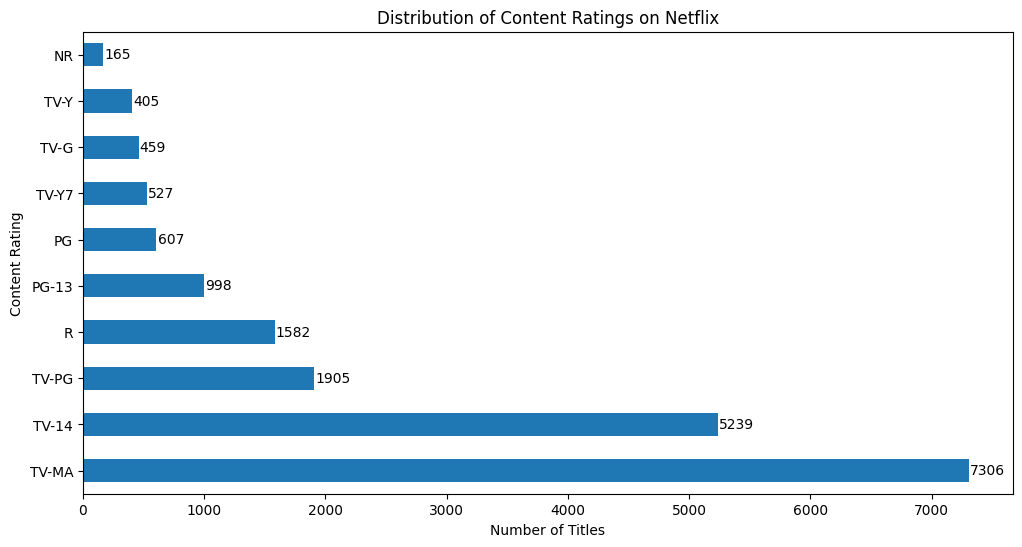

In [49]:
ac=rating_counts.plot(kind='barh',figsize=(12,6))
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Content Rating')

for l , n in enumerate(rating_counts):
  ac.text(n+10,l,str(n),va='center')

plt.show()

# **Key Insights**

1. TV-MA is the most common content rating on Netflix, indicating that a large portion of the catalog is intended for mature audiences.

2. TV-14 is the second most common content rating, showing that content suitable for teenagers and older viewers is also well represented.

3. NR has one of the lowest numbers of titles among the Top 10 ratings, making it one of the least represented content ratings in the dataset.

# ***FINAL CONCLUSIONS***

1. Movies constitute the majority of Netflix's catalog, significantly outnumbering TV Shows.

2. International Movies, Dramas, and Comedies are among the most common genres available on Netflix.

3. The United States contributes the highest number of titles, making it the largest content-producing country in the dataset.

4. Netflix experienced rapid growth in content additions between 2016 and 2019, with 2019 being the peak year.

5. Both Movies and TV Shows followed a similar growth pattern, reaching their highest number of additions in 2019 before declining in subsequent years.

6. TV-MA and TV-14 are the most common content ratings, indicating that a large portion of Netflix's catalog is targeted toward mature and teenage audiences.